# TQC on BipedalWalker

Truncated Quantile Critics (TQC) agent for the BipedalWalker environments, written on top of a Soft Actor-Critic base. Configured below for the hardcore course; pass `hardcore=False` to `make_walker(...)` for the standard one.

See the repository [README](../README.md) for results, hyperparameters and the full write-up.

### Differences from standard TQC
- Only 2 critics rather than the usual 5+ (compute constraint).
- Quantiles are not merged across critics before truncation; each critic is truncated separately and the critics are then combined with an element-wise `min`.
- An elite replay buffer sits alongside the uniform buffer: trajectories from episodes above the 90th reward percentile are stored separately and make up 25% of each training batch.
- Observation normalisation (running mean/variance).
    - https://github.com/openai/baselines/blob/master/baselines/common/running_mean_std.py
- A small forward-velocity bonus rewards the agent for moving faster.
    - I. Popov et al., "Data-efficient Deep Reinforcement Learning for Dexterous Manipulation," arXiv:1704.03073, Apr. 2017. https://arxiv.org/abs/1704.03073

### References
- A. Kuznetsov, P. Shvechikov, A. Grishin, and D. Vetrov, "Controlling Overestimation Bias with Truncated Mixture of Continuous Distributional Quantile Critics," PMLR, pp. 5556-5566, 2020. https://proceedings.mlr.press/v119/kuznetsov20a.html
- "TQC - Stable Baselines3 - Contrib 2.6.0 documentation," 2021. https://sb3-contrib.readthedocs.io/en/master/modules/tqc.html
- T. Haarnoja et al., "Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor," arXiv:1801.01290, 2018. https://arxiv.org/abs/1801.01290

In [ ]:
import os
import sys
import random
from collections import deque
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Environment, recording and plotting helpers live in src/walker_utils.py.
sys.path.append(str(Path.cwd().parent / "src"))
import walker_utils as wu

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RunningNormalizer:
    def __init__(self, shape):
        self.mean = np.zeros(shape, dtype=np.float32)
        self.var = np.ones(shape, dtype=np.float32)
        self.count = 1e-4

    def update(self, x):
        batch_mean = np.mean(x, axis=0)
        batch_var = np.var(x, axis=0)
        batch_count = x.shape[0]

        delta = batch_mean - self.mean
        tot_count = self.count + batch_count

        self.mean += delta * batch_count / tot_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + (delta ** 2) * self.count * batch_count / tot_count
        self.var = M2 / tot_count
        self.count = tot_count

    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + 1e-8)


def quantile_huber_loss(preds, target, taus):
    target = target.expand_as(preds).detach()
    td_error = target - preds
    huber_loss = F.smooth_l1_loss(preds, target, reduction="none")
    weight = torch.abs(taus - (td_error < 0).float())
    return (weight * huber_loss).mean()

class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=256):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        return self.net(x)

class MLP(nn.Module):
    def __init__(self, *sizes, activation=nn.ReLU):
        super().__init__()
        layers = []
        for i in range(len(sizes) - 2):
            layers += [nn.Linear(sizes[i], sizes[i + 1]), activation()]
        layers += [nn.Linear(sizes[-2], sizes[-1])]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(256, 256), log_std_bounds=(-20, 2)):
        super().__init__()
        self.net = MLP(obs_dim, *hidden_sizes, act_dim * 2)
        self.log_std_bounds = log_std_bounds

    def forward(self, obs):
        mu_log_std = self.net(obs)
        mu, log_std = torch.chunk(mu_log_std, 2, dim=-1)
        log_std = torch.clamp(log_std, *self.log_std_bounds)
        std = torch.exp(log_std)
        return mu, std

    def sample(self, obs):
        mu, std = self.forward(obs)
        dist = torch.distributions.Normal(mu, std)
        z = dist.rsample()
        action = torch.tanh(z)

        logp = dist.log_prob(z).sum(-1, keepdim=True)
        logp -= (2 * (np.log(2) - z - F.softplus(-2 * z))).sum(-1, keepdim=True)
        return action, logp

class QuantileCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(256, 256), n_quantiles=25):
        super().__init__()
        self.n_quantiles = n_quantiles
        self.net = MLP(obs_dim + act_dim, *hidden_sizes, n_quantiles)

    def forward(self, obs, act):
        x = torch.cat([obs, act], dim=-1)
        return self.net(x)

class ReplayBuffer:
    def __init__(self, max_size=1_000_000):
        self.buffer = deque(maxlen=max_size)

    def __len__(self):
        return len(self.buffer)

    def store(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(len(self.buffer), batch_size))
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(state).to(device),
            torch.FloatTensor(action).to(device),
            torch.FloatTensor(reward).unsqueeze(1).to(device),
            torch.FloatTensor(next_state).to(device),
            torch.FloatTensor(done).unsqueeze(1).to(device)
        )
    
class EliteReplayBuffer:
    def __init__(self, max_size=10000):
        self.buffer = deque(maxlen=max_size)

    def __len__(self):
        return len(self.buffer)

    def store(self, trajectory):
        self.buffer.extend(trajectory)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(len(self.buffer), batch_size))
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(state).to(device),
            torch.FloatTensor(action).to(device),
            torch.FloatTensor(reward).unsqueeze(1).to(device),
            torch.FloatTensor(next_state).to(device),
            torch.FloatTensor(done).unsqueeze(1).to(device)
        )
    
class TQCAgent:
    def __init__(self,
                 obs_dim,
                 act_dim,
                 max_action=1.0,
                 gamma=0.99,
                 tau=0.005,
                 alpha=0.2,
                 lr=3e-4):
        
        
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.gamma = gamma
        self.tau = tau
        self.max_action = max_action

        self.actor = GaussianPolicy(obs_dim, act_dim).to(device)
        n_quantiles = 25
        self.n_drop = 2

        self.q1 = QuantileCritic(obs_dim, act_dim, n_quantiles=n_quantiles).to(device)
        self.q2 = QuantileCritic(obs_dim, act_dim, n_quantiles=n_quantiles).to(device)
        self.q1_target = QuantileCritic(obs_dim, act_dim, n_quantiles=n_quantiles).to(device)
        self.q2_target = QuantileCritic(obs_dim, act_dim, n_quantiles=n_quantiles).to(device)

        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        self.actor_opt = optim.Adam(self.actor.parameters(), lr=lr)
        self.q_opt = optim.Adam(list(self.q1.parameters()) + list(self.q2.parameters()), lr=lr)

        self.target_entropy = -act_dim
        self.log_alpha = torch.tensor(np.log(alpha), requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=lr)

        self.replay = ReplayBuffer()
        self.elite_replay = EliteReplayBuffer()
        self.total_it = 0
        self.obs_normalizer = RunningNormalizer(obs_dim)

    def act(self, obs, eval_mode=False):
        norm_obs = self.obs_normalizer.normalize(np.array(obs))
        obs = torch.FloatTensor(norm_obs).unsqueeze(0).to(device)
        with torch.no_grad():
            action, _ = self.actor.sample(obs)
        action = action.cpu().numpy().flatten()
        return action if not eval_mode else np.clip(action, -self.max_action, self.max_action)

    def train(self, batch_size=256):
        if len(self.replay.buffer) < batch_size:
            return
        
        elite_fraction = 0.25  # 25% are elite
        elite_size = int(batch_size * elite_fraction)

        use_elite = len(self.elite_replay) >= elite_size

        if use_elite:
            elite_batch = self.elite_replay.sample(elite_size)
            normal_batch = self.replay.sample(batch_size - elite_size)

            obs = torch.cat([normal_batch[0], elite_batch[0]], dim=0)
            act = torch.cat([normal_batch[1], elite_batch[1]], dim=0)
            rew = torch.cat([normal_batch[2], elite_batch[2]], dim=0)
            next_obs = torch.cat([normal_batch[3], elite_batch[3]], dim=0)
            done = torch.cat([normal_batch[4], elite_batch[4]], dim=0)
        else:
            obs, act, rew, next_obs, done = self.replay.sample(batch_size)
            
        with torch.no_grad():
            next_action, next_logp = self.actor.sample(next_obs)
            q1_next = self.q1_target(next_obs, next_action)
            q2_next = self.q2_target(next_obs, next_action)

            q1_sorted, _ = torch.sort(q1_next, dim=1)
            q2_sorted, _ = torch.sort(q2_next, dim=1)

            q1_trunc = q1_sorted[:, self.n_drop:]
            q2_trunc = q2_sorted[:, self.n_drop:]

            q_target = torch.min(q1_trunc, q2_trunc).mean(dim=1, keepdim=True)
            backup = rew + self.gamma * (1 - done) * (q_target - self.log_alpha.exp() * next_logp)
        
        last_linear = [m for m in self.q1.net.model if isinstance(m, nn.Linear)][-1]
        tau = torch.linspace(0.5 / last_linear.out_features, 1 - 0.5 / last_linear.out_features, last_linear.out_features).view(1, -1).to(device)
        
        q1_pred = self.q1(obs, act)
        q2_pred = self.q2(obs, act)

        q1_loss = quantile_huber_loss(q1_pred, backup, tau)
        q2_loss = quantile_huber_loss(q2_pred, backup, tau)

        self.q_opt.zero_grad()
        (q1_loss + q2_loss).backward()
        self.q_opt.step()

        new_action, logp = self.actor.sample(obs)
        q1_pi = self.q1(obs, new_action)
        q2_pi = self.q2(obs, new_action)
        q_pi = torch.min(q1_pi, q2_pi)

        actor_loss = (self.log_alpha.exp() * logp - q_pi).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        alpha_loss = -(self.log_alpha * (logp + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()

        for param, target_param in zip(self.q1.parameters(), self.q1_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        for param, target_param in zip(self.q2.parameters(), self.q2_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

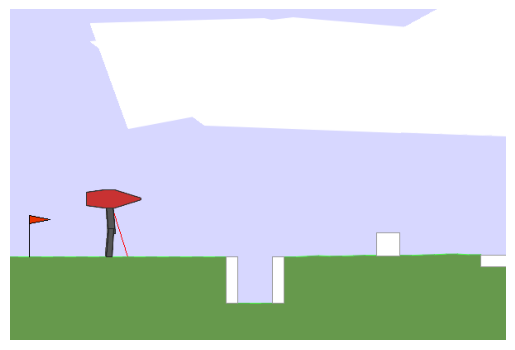

In [ ]:
env = wu.make_walker(hardcore=True, render_mode="rgb_array")

env = wu.Recorder(
    env,
    smoothing=10,
    video=True,
    video_folder="videos-TQC_Hardcore",
    video_prefix="agent-hardcore-video",
    video_every=50,
    logs=True,
)

wu.check_device()
discrete_act, discrete_obs, act_dim, obs_dim = wu.env_info(env, print_out=True)
env.reset(seed=42)
wu.render(env)

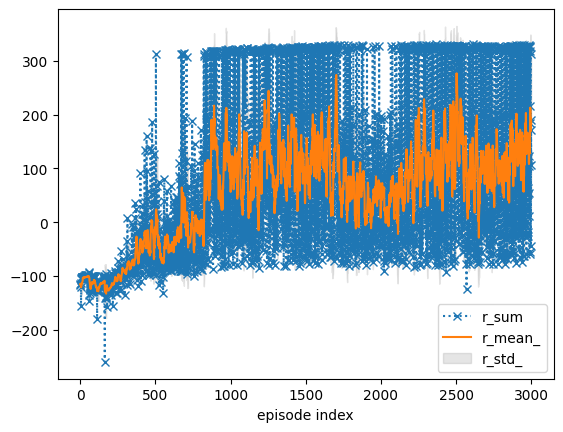

In [ ]:
seed, observation, info = wu.seed_everything(42, env)

agent = TQCAgent(obs_dim=obs_dim, act_dim=act_dim, max_action=1.0)

max_episodes = 3000
max_timesteps = 2000

# Track stats
tracker = wu.InfoTracker()

reward_history = []

for episode in range(max_episodes):
    obs, info = env.reset()
    episode_buffer = []
    episode_reward = 0.0

    for t in range(max_timesteps):
        # Stabilise after 500 eps
        action = agent.act(obs, eval_mode=(episode >= 500))

        next_obs, reward, terminated, truncated, info = env.step(action)

        agent.replay.store(obs, action, reward, next_obs, terminated or truncated)
        episode_buffer.append((obs, action, reward, next_obs, terminated or truncated))

        agent.train(batch_size=256)

        # adds a reward for moving faster
        forward_bonus = 0.1 * (next_obs[0] - obs[0])
        reward += forward_bonus
        obs = next_obs
        episode_reward += reward


        if terminated or truncated:
            break

    reward_history.append(episode_reward)
    elite_threshold = np.percentile(reward_history, 90) if len(reward_history) >= 20 else -np.inf

    if episode_reward > elite_threshold:
        agent.elite_replay.store(episode_buffer)
    print(f"[Episode {episode+1}] Reward: {episode_reward:.1f}, Length: {t+1}")


    # Track / plot
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_sum=True, r_mean_=True, r_std_=True)

env.close()
env.write_log(folder="logs-TQC_Hardcore", file="agent-hardcore-log.txt")

In [ ]:
# Scripted baseline gait, for comparison against the learned policy.
from gymnasium.envs.box2d.bipedal_walker import BipedalWalkerHeuristics

env = wu.make_walker(hardcore=True, render_mode="human")
_, obs, info = wu.seed_everything(42, env)

heuristics = BipedalWalkerHeuristics()

act = heuristics.step_heuristic(obs)
for _ in range(500):
    obs, rew, terminated, truncated, info = env.step(act)
    act = heuristics.step_heuristic(obs)
    if terminated or truncated:
        break
    if env.render_mode == "rgb_array":
        wu.render(env, clear=True)
env.close()